In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re
from unidecode import unidecode
import numpy as np
import recordlinkage
from collections import defaultdict
import pandas as pd
from rapidfuzz import fuzz  
!pip install fuzzywuzzy
!pip install recordlinkage 

# below is the article that will be my guide for this
#https://spotintelligence.com/2024/01/22/entity-resolution/

# Understanding the dataset

In [2]:
df = pd.read_csv("QUB_Analytathon2_Deloitte_data.csv")
df2 = df.copy()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5186 entries, 0 to 5185
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   prefix          5186 non-null   object
 1   first_name      5186 non-null   object
 2   middle_name     2630 non-null   object
 3   last_name       5186 non-null   object
 4   date_of_birth   1924 non-null   object
 5   email_address   3318 non-null   object
 6   phone_number    3299 non-null   object
 7   house_no        3678 non-null   object
 8   primary_street  3678 non-null   object
 9   town            3678 non-null   object
 10  postcode        3678 non-null   object
 11  county          3678 non-null   object
dtypes: object(12)
memory usage: 486.3+ KB


In [4]:
df.isnull().sum()

prefix               0
first_name           0
middle_name       2556
last_name            0
date_of_birth     3262
email_address     1868
phone_number      1887
house_no          1508
primary_street    1508
town              1508
postcode          1508
county            1508
dtype: int64

In [5]:
df.head()

,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county
0,Mr,Kyle,NaN,Taylor,2000-03-21,NaN,NaN,20,Begum Courts,Katesbridge,BT18 1PR,Down
1,Mrs,Katy,Nicole,Rogers,NaN,katy.rogers@yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN
2,Mr,Stewart,NaN,Carey,NaN,stewartccarey979@hotmail.co.uk,+447700900711,145,Harper Dam,Magheramason,BT21 3QY,Down
3,Mr,Charles,NaN,Clarke,NaN,charles.clarke@hotmail.co.uk,NaN,6,Holt Manors,Erganagh,BT55 9OF,Derry_Londonderry
4,Mrs,Bethan,Michelle,Bell,NaN,bethanbell@hotmail.co.uk,NaN,36,Dixon Island,Ballymagorry,BT63 1OJ,Armagh


# Standardising data, (lower case, removing white space, accents etc.)

In [6]:
# **** By ANDREW SCOTT 
# Need to standardise data. Changing all strings to either lower case or upper case.
# How to deal with phone_number 
# what about date of birth, different formats?
# to help with string manipulation:
# https://medium.com/@ariefwcks303/python-cleaning-data-with-pandas-part-8-string-manipulation-with-pandas-6393e0d7fd3c
# First I'll change all columns with text to lower case and remove excess spaces.

for col in df:
    df[col] = df[col].str.lower().str.strip()

df['postcode'] = df['postcode'].str.replace(' ', '')
df['county'] = df['county'].str.replace(' ','')
df['county'] = df['county'].str.replace('_','')


In [7]:
df.head()

,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county
0,mr,kyle,NaN,taylor,2000-03-21,NaN,NaN,20,begum courts,katesbridge,bt181pr,down
1,mrs,katy,nicole,rogers,NaN,katy.rogers@yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN
2,mr,stewart,NaN,carey,NaN,stewartccarey979@hotmail.co.uk,+447700900711,145,harper dam,magheramason,bt213qy,down
3,mr,charles,NaN,clarke,NaN,charles.clarke@hotmail.co.uk,NaN,6,holt manors,erganagh,bt559of,derrylondonderry
4,mrs,bethan,michelle,bell,NaN,bethanbell@hotmail.co.uk,NaN,36,dixon island,ballymagorry,bt631oj,armagh


In [8]:
# BY ANDREW SCOTT
# What if data has accents? Or special characters?
# What do we do with missing values?
# Some very important, so use them if they're available?
# What columns do we keep? Do we keep them all?

# Dealing with accents
# https://stackoverflow.com/questions/67508525/remove-accents-from-a-python-dataframe
# https://stackoverflow.com/questions/26614465/python-pandas-apply-function-if-a-column-value-is-not-null
for col in df:
    df[col] = df[col].apply(lambda x: unidecode(x) if pd.notna(x) else x)
    
    

# First changing date_of_birth column to date time to ensure all in same format
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])


# Will deal with removing special characters later, after Vinays code as it will affect his code

In [9]:
unique_vals_columns = ['prefix', 'county']
for col in unique_vals_columns:
    print(f'Unique values for {col} are:\n ',df[col].unique())

Unique values for prefix are:
  ['mr' 'mrs' 'ms' 'miss']
Unique values for county are:
  ['down' nan 'derrylondonderry' 'armagh' 'fermanagh' 'tyrone' 'antrim']


# Looking at identical entries for email_address column

In [10]:
# BY ANDREW SCOTT
# https://stackoverflow.com/questions/34810358/how-to-find-duplicates-in-pandas
# removing observations where email_address is NaN
df_without_email_nas = df[df['email_address'].notna()]

# geting only duplicate email rows and sorting by email_address 
df_simple_email_dupes = df_without_email_nas[df_without_email_nas['email_address'].duplicated(keep=False)]
df_simple_email_dupes_sorted = df_simple_email_dupes.sort_values(['email_address'])

df_simple_email_dupes_sorted


,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county
813,mr,adrian,NaN,barrett,NaT,abarrett@hotmail.co.uk,NaN,40,grant streets,lisburn,bt639io,armagh
276,mr,adrian,NaN,barrett,NaT,abarrett@hotmail.co.uk,07700900727,40,grant streets,lisburn,bt639io,armagh
5022,ms,abbie,hazel,fletcher,NaT,abbie.fletcher@yahoo.com,07700 900909,NaN,NaN,NaN,NaN,NaN
2580,ms,abbie,hazel,fletcher,NaT,abbie.fletcher@yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN
1371,mr,abdul,denis,smith,NaT,abduldsmith@yahoo.com,07700900052,88,booth glen,derrylin,bt692rw,tyrone
...,...,...,...,...,...,...,...,...,...,...,...,...
1733,mrs,yvonne,NaN,greenwood,NaT,yvonnegreenwood@yahoo.co.uk,NaN,32,wayne junctions,garvetagh,bt740ht,fermanagh
4249,ms,yvonne,sara,vaughan,NaT,yvonnesvaughan414@hotmail.co.uk,07700 900221,198,chloe manors,donaghey,bt939sc,fermanagh
2482,ms,yvonne,sara,vaughan,NaT,yvonnesvaughan414@hotmail.co.uk,4407700 900221,198,chloe manors,donaghey,bt939sc,fermanagh
3235,ms,zoe,fiona,evans,NaT,zoe.evans@hotmail.com,07700900070,123c,higgins stravenue,dunmurry,bt487ie,derrylondonderry


In [11]:
# BY ANDREW SCOTT
# https://stackoverflow.com/questions/53100242/pandas-count-number-of-occurrences-of-values-in-one-column
# creating a dataframe to see how many times each duplicated email is seen in the original dataframe
df_simple_email_dupes_counted = df_simple_email_dupes.copy()
df_simple_email_dupes_counted = df_simple_email_dupes_counted['email_address'].value_counts().to_frame().reset_index().rename(columns={'index':'email_address', 'email_address':'Count'})
df_simple_email_dupes_counted

,email_address,Count
0,connor325@outlook.com,4
1,bethany.smith@outlook.com,3
2,philip381@outlook.com,3
3,callum288@outlook.com,3
4,dianeeturner@yahoo.com,3
...,...,...
762,cherylrobson@hotmail.co.uk,2
763,joshua.thorpe@yahoo.com,2
764,georgia134@hotmail.co.uk,2
765,glennnwright@yahoo.co.uk,2


In [12]:
# BY ASCOTT
# seeing entries with most duplicated emails. can see they used different surnames.
df[df['email_address'] == 'bethany.smith@outlook.com']

,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county
553,miss,bethany,NaN,smith,1972-12-08,bethany.smith@outlook.com,07700 900064,144,carole knolls,belleeks,bt249qb,down
1680,miss,bethany,NaN,smith,1972-12-08,bethany.smith@outlook.com,07700 900064,144,carole knolls,belleeks,bt249qb,down
2208,miss,bethany,NaN,smith,1972-12-08,bethany.smith@outlook.com,07700 900064,NaN,NaN,NaN,NaN,NaN


In [13]:
# BY ASCOTT
# creating a df showing how many times an email entry is seen, with index being amount of times
df_occurence_email_dupes = df_simple_email_dupes_counted['Count'].value_counts().to_frame().reset_index()
df_occurence_email_dupes.columns = ["Email Occurrences", "Count"]
df_occurence_email_dupes


,Email Occurrences,Count
0,2,737
1,3,29
2,4,1


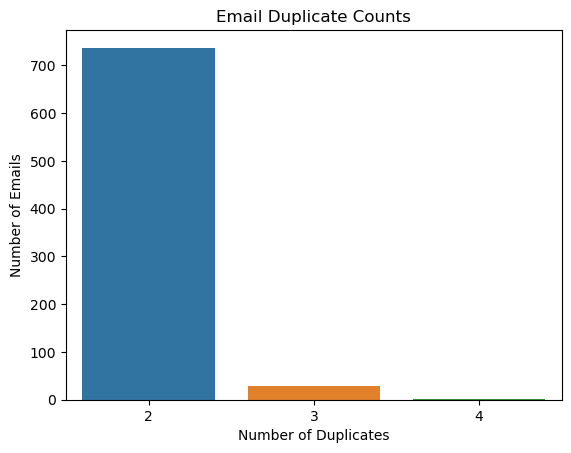

In [14]:
sns.barplot(x=df_occurence_email_dupes['Email Occurrences'], y=df_occurence_email_dupes['Count'])
plt.xlabel("Number of Duplicates")
plt.ylabel("Number of Emails")
plt.title("Email Duplicate Counts")
plt.show()

In [15]:
# BY ANDREW SCOTT
# Few things here, from this simple email address duplicate check we see that there are 1565 rows involved
# Another thing, I've noticed the phone numbers are displayed quite different, some have a space after the first 4 
# official phone numbers (not including country code). Also when country code is included its seems to be a mix of
# +447, 447, +4407, 4407, 07 etc

# need to remove space in phone number as we did with postcode.
df['phone_number'] = df['phone_number'].str.replace(' ', '')



# https://stackoverflow.com/questions/34810358/how-to-find-duplicates-in-pandas
# removing observations where email_address is NaN
df_without_email_nas = df[df['email_address'].notna()]

# geting only duplicate email rows and sorting by email_address 
df_simple_email_dupes = df_without_email_nas[df_without_email_nas['email_address'].duplicated(keep=False)]
df_simple_email_dupes_sorted = df_simple_email_dupes.sort_values(['email_address'])

df_simple_email_dupes_sorted['duplicate_score'] = 100

df_simple_email_dupes_sorted



,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county,duplicate_score
813,mr,adrian,NaN,barrett,NaT,abarrett@hotmail.co.uk,NaN,40,grant streets,lisburn,bt639io,armagh,100
276,mr,adrian,NaN,barrett,NaT,abarrett@hotmail.co.uk,07700900727,40,grant streets,lisburn,bt639io,armagh,100
5022,ms,abbie,hazel,fletcher,NaT,abbie.fletcher@yahoo.com,07700900909,NaN,NaN,NaN,NaN,NaN,100
2580,ms,abbie,hazel,fletcher,NaT,abbie.fletcher@yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN,100
1371,mr,abdul,denis,smith,NaT,abduldsmith@yahoo.com,07700900052,88,booth glen,derrylin,bt692rw,tyrone,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,mrs,yvonne,NaN,greenwood,NaT,yvonnegreenwood@yahoo.co.uk,NaN,32,wayne junctions,garvetagh,bt740ht,fermanagh,100
4249,ms,yvonne,sara,vaughan,NaT,yvonnesvaughan414@hotmail.co.uk,07700900221,198,chloe manors,donaghey,bt939sc,fermanagh,100
2482,ms,yvonne,sara,vaughan,NaT,yvonnesvaughan414@hotmail.co.uk,4407700900221,198,chloe manors,donaghey,bt939sc,fermanagh,100
3235,ms,zoe,fiona,evans,NaT,zoe.evans@hotmail.com,07700900070,123c,higgins stravenue,dunmurry,bt487ie,derrylondonderry,100


In [16]:
# writing the identical email duplicates to csv file
df_simple_email_dupes_sorted.to_csv('identical_email_duplicates.csv', index= False)

In [17]:

# Way to deal with phone_number is knowing that there are 10 numbers in it not including the first 0
# So bringing the length of the phone_number strings down to 10

# **** code shared by Vinay to manage phone number ****
# function to standardize the phone number
def standardize_phone_number(phone):
    if pd.isna(phone):
        return phone
        
    phone = str(phone).strip()
    phone = re.sub(r'\s+', '', phone) 
    if len(phone) == 14 and phone.startswith('+440'):
        return '0' + phone[4:]
        
    # Replace +44 with 0 if length is 13 and starts with +44 or 440
    elif len(phone) == 13 and (phone.startswith('+44') or phone.startswith('440')):
        return '0' + phone[3:]
        
    # Replace 44 with 0 if length is 12 and starts with 44
    elif len(phone) == 12 and phone.startswith('44'):
        return '0' + phone[2:]

     # If length is 11 and starts with 0, leave it as it is
    elif len(phone) == 11 and phone.startswith('0'):      
        return phone

     # If length is 10 and doesn't start with 0, prepend 0
    elif len(phone) == 10 and not phone.startswith('0'):
        return '0' + phone
    
    return phone  

df['phone_number'] = df['phone_number'].apply(standardize_phone_number)
df.head(10)


df

,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county
0,mr,kyle,NaN,taylor,2000-03-21,NaN,NaN,20,begum courts,katesbridge,bt181pr,down
1,mrs,katy,nicole,rogers,NaT,katy.rogers@yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN
2,mr,stewart,NaN,carey,NaT,stewartccarey979@hotmail.co.uk,07700900711,145,harper dam,magheramason,bt213qy,down
3,mr,charles,NaN,clarke,NaT,charles.clarke@hotmail.co.uk,NaN,6,holt manors,erganagh,bt559of,derrylondonderry
4,mrs,bethan,michelle,bell,NaT,bethanbell@hotmail.co.uk,NaN,36,dixon island,ballymagorry,bt631oj,armagh
...,...,...,...,...,...,...,...,...,...,...,...,...
5181,mr,jeremy,NaN,burton,1980-08-23,jeremytburton983@yahoo.com,07700900645,189,howard mill,gamblestown,bt532xi,antrim
5182,mr,jeffrey,hugh,smith,NaT,jeffreysmith@gmail.com,07700900218,NaN,NaN,NaN,NaN,NaN
5183,miss,kathleen,NaN,dixon,NaT,kathleendixon@yahoo.co.uk,NaN,33,abdul streets,halfpenny gate,bt920gi,fermanagh
5184,ms,rosemary,katie,andrews,1995-04-26,rosemarykandrews@yahoo.com,07700900377,103,hughes mission,broomhill,bt126yr,antrim


In [18]:
# **** BY ANDREW SCOTT
# Removing special characters:
# code taken from: 
# https://saturncloud.io/blog/how-to-remove-special-characters-in-pandas-dataframe/#:~:text=Use%20Regex%20Substitution%3A&text=sub()%20function%20from%20the,)%2C%20effectively%20removing%20special%20characters.
# will apply it to all my columns, not just one as given:

# defining  the regular expression pattern
pattern = r'[^\w\s]'

for col in df:
    # skipping the email_address column because the special characters are important
    if col == 'email_address':
        continue
    df[col] = df[col].replace(pattern, '', regex=True)

df

,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county
0,mr,kyle,NaN,taylor,2000-03-21,NaN,NaN,20,begum courts,katesbridge,bt181pr,down
1,mrs,katy,nicole,rogers,NaT,katy.rogers@yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN
2,mr,stewart,NaN,carey,NaT,stewartccarey979@hotmail.co.uk,07700900711,145,harper dam,magheramason,bt213qy,down
3,mr,charles,NaN,clarke,NaT,charles.clarke@hotmail.co.uk,NaN,6,holt manors,erganagh,bt559of,derrylondonderry
4,mrs,bethan,michelle,bell,NaT,bethanbell@hotmail.co.uk,NaN,36,dixon island,ballymagorry,bt631oj,armagh
...,...,...,...,...,...,...,...,...,...,...,...,...
5181,mr,jeremy,NaN,burton,1980-08-23,jeremytburton983@yahoo.com,07700900645,189,howard mill,gamblestown,bt532xi,antrim
5182,mr,jeffrey,hugh,smith,NaT,jeffreysmith@gmail.com,07700900218,NaN,NaN,NaN,NaN,NaN
5183,miss,kathleen,NaN,dixon,NaT,kathleendixon@yahoo.co.uk,NaN,33,abdul streets,halfpenny gate,bt920gi,fermanagh
5184,ms,rosemary,katie,andrews,1995-04-26,rosemarykandrews@yahoo.com,07700900377,103,hughes mission,broomhill,bt126yr,antrim


# If one location column has an entry, does this mean all location columns have an entry?

In [19]:
# BY ANDREW SCOTT
# Before moving on to dealing with the identical email addresses 
# I also want to look at whether location information always appears together, or if atleast 2
# location information columns have entries if there is an entry for the location information

location_info_cols = ['house_no', 'primary_street', 'town', 'postcode', 'county']

# https://stackoverflow.com/questions/43424199/display-rows-with-one-or-more-nan-values-in-pandas-dataframe
# used this code but iterated it over the columns I want to check
for column in location_info_cols:
    df1 = df[df[column].notna() & df[location_info_cols].isna().any(axis=1)]
    print(f'Returning rows where all location columns arent filled, for "{column}": ')
    print(df1, '\n')

# This tells us that whenever one location information column is present the rest are. 
# This is useful for our search! We can look for those with same addresses as possibile duplicated
# Although could be multiple people living at one house.

Returning rows where all location columns arent filled, for "house_no": 
Empty DataFrame
Columns: [prefix, first_name, middle_name, last_name, date_of_birth, email_address, phone_number, house_no, primary_street, town, postcode, county]
Index: [] 

Returning rows where all location columns arent filled, for "primary_street": 
Empty DataFrame
Columns: [prefix, first_name, middle_name, last_name, date_of_birth, email_address, phone_number, house_no, primary_street, town, postcode, county]
Index: [] 

Returning rows where all location columns arent filled, for "town": 
Empty DataFrame
Columns: [prefix, first_name, middle_name, last_name, date_of_birth, email_address, phone_number, house_no, primary_street, town, postcode, county]
Index: [] 

Returning rows where all location columns arent filled, for "postcode": 
Empty DataFrame
Columns: [prefix, first_name, middle_name, last_name, date_of_birth, email_address, phone_number, house_no, primary_street, town, postcode, county]
Index: [] 

Re

# How do we approach dealing with duplicate data? (aggregating rows)

In [20]:
# BY ASCOTT
# Question is how to deal with duplicate data. 
# Dont want to miss out on important information for each customer, 
# so want to aggregrate all rows for each customer into one 

# https://stackoverflow.com/questions/58179593/how-to-combine-join-and-lambda-x-x-tolist-inside-an-groupby-agg-functio
# https://stackoverflow.com/questions/70650545/pandas-agg-convert-to-list-but-skip-nans

# going to test it on just these 4 duplicate rows as we saw above
df_test = df[df['email_address'] == 'bethany.smith@outlook.com']


df_combined = df_test.groupby('email_address', as_index=False).agg({
    'prefix': lambda x: ' '.join(x.dropna().unique()),  
    'first_name': lambda x: ' '.join(x.dropna().unique()),  
    'middle_name': lambda x: ' '.join(x.dropna().unique()),  
    'last_name': lambda x: ' '.join(x.dropna().unique()),  
    'date_of_birth': 'first',  
    'phone_number': lambda x: ' '.join(x.dropna().unique()),  
    'house_no': lambda x: ' '.join(x.dropna().unique()),  
    'primary_street': lambda x: ' '.join(x.dropna().unique()), 
    'town': lambda x: ' '.join(x.dropna().unique()),  
    'postcode': lambda x: ' '.join(x.dropna().unique()),  
    'county': lambda x: ' '.join(x.dropna().unique()),  
    'phone_number': lambda x: ' '.join(x.dropna().unique()), 
})


# returns what we want, aggregates data from multiple rows into one
# this only returns the data from the rows which have email addresses what about no email address have to include them

df_combined

,email_address,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,house_no,primary_street,town,postcode,county
0,bethany.smith@outlook.com,miss,bethany,,smith,1972-12-08,07700900064,144,carole knolls,belleeks,bt249qb,down


In [21]:
# just to compare with the aggregated row above
df_test

,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county
553,miss,bethany,NaN,smith,1972-12-08,bethany.smith@outlook.com,07700900064,144,carole knolls,belleeks,bt249qb,down
1680,miss,bethany,NaN,smith,1972-12-08,bethany.smith@outlook.com,07700900064,144,carole knolls,belleeks,bt249qb,down
2208,miss,bethany,NaN,smith,1972-12-08,bethany.smith@outlook.com,07700900064,NaN,NaN,NaN,NaN,NaN


In [22]:
# NOT SURE WHERE TO GO.... SHOULD I KEEP THE DATA COMBINED, DOES IT AFFECT THE FUZZY STUFF

# Aggregating identical rows into one row for email_address column

In [23]:
# BY ASCOTT
# separating the rows with nans and creating a df
df_nan = df[df['email_address'].isna()]
df_without_nan = df[df['email_address'].notna()]

# creating df for aggregated rows done by email address
# applying to whole dataframe, will check for emails with same string, and aggregate data
df_agg_email = df_without_nan.groupby('email_address', as_index=False).agg({
    'prefix': lambda x: ' '.join(x.dropna().unique()),  
    'first_name': lambda x: ' '.join(x.dropna().unique()),  
    'middle_name': lambda x: ' '.join(x.dropna().unique()),  
    'last_name': lambda x: ' '.join(x.dropna().unique()),  
    'date_of_birth': 'first',  
    'phone_number': lambda x: ' '.join(x.dropna().unique()),  
    'house_no': lambda x: ' '.join(x.dropna().unique()),  
    'primary_street': lambda x: ' '.join(x.dropna().unique()), 
    'town': lambda x: ' '.join(x.dropna().unique()),  
    'postcode': lambda x: ' '.join(x.dropna().unique()),  
    'county': lambda x: ' '.join(x.dropna().unique()),  
    'phone_number': lambda x: ' '.join(x.dropna().unique())
})


df_agg_email

,email_address,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,house_no,primary_street,town,postcode,county
0,aaron308@outlook.com,mr,aaron,jay,simpson,1992-01-26,07700900243,164,sullivan inlet,eglish,bt943ri,fermanagh
1,aaron339@hotmail.co.uk,mr,aaron,vincent,dixon,NaT,07700900690,27,fletcher fall,glenavy,bt806ak,tyrone
2,aarontlewis@gmail.com,mr,aaron,,lewis,NaT,07700900084,148,lee shoals,bellaghy,bt374ey,antrim
3,aaronvlawrence100@yahoo.co.uk,mr,aaron,,lawrence,NaT,07700900653,86,wheeler courts,tullynacross,bt684pf,tyrone
4,abarrett@hotmail.co.uk,mr,adrian,,barrett,NaT,07700900727,40,grant streets,lisburn,bt639io,armagh
...,...,...,...,...,...,...,...,...,...,...,...,...
2515,zoe.evans@hotmail.com,ms,zoe,fiona,evans,NaT,07700900070,123c,higgins stravenue,dunmurry,bt487ie,derrylondonderry
2516,zoe.lawrence@gmail.com,mrs,zoe,,lawrence,NaT,,92,peter squares,gracehill,bt237rk,down
2517,zoebdavison803@hotmail.com,mrs,zoe,,davison,NaT,,168b,howard parks,skea,bt921rn,fermanagh
2518,zoecollins@yahoo.com,mrs,zoe,,collins,NaT,07700900628,118,russell springs,ballynure,bt156mb,antrim


In [24]:
# writing the aggregated email rows to a csv file so we have a record
df_agg_email.to_csv('rows_grouped_by_email_aggregated.csv', index = False)

In [25]:
# Need to check if this is the amount of rows expected
# we saw there are 1868 rows with NaNs for email_address,
# we aggregated rows which have same email address into one
# 737 rows had 2 entries for email, so 737 rows removed
# 29 rows had 3 entries for email, so 2*29 = 58 rows removed
# 1 row had 4 entries for email, so 3 rows removed
# total rows removed/dealt with it 737+58+3, 798
# total rows at start in df is 5186,
# expected rows is 5186-798 = 4388, which is what we have in df_emails_aggregated
df_emails_aggregated = pd.concat([df_agg_email, df_nan], ignore_index=True)
df_emails_aggregated

,email_address,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,house_no,primary_street,town,postcode,county
0,aaron308@outlook.com,mr,aaron,jay,simpson,1992-01-26,07700900243,164,sullivan inlet,eglish,bt943ri,fermanagh
1,aaron339@hotmail.co.uk,mr,aaron,vincent,dixon,NaT,07700900690,27,fletcher fall,glenavy,bt806ak,tyrone
2,aarontlewis@gmail.com,mr,aaron,,lewis,NaT,07700900084,148,lee shoals,bellaghy,bt374ey,antrim
3,aaronvlawrence100@yahoo.co.uk,mr,aaron,,lawrence,NaT,07700900653,86,wheeler courts,tullynacross,bt684pf,tyrone
4,abarrett@hotmail.co.uk,mr,adrian,,barrett,NaT,07700900727,40,grant streets,lisburn,bt639io,armagh
...,...,...,...,...,...,...,...,...,...,...,...,...
4383,NaN,miss,denise,leanne,daniels,NaT,07700900265,164,harriet gardens,killadeas,bt742kn,fermanagh
4384,NaN,mr,mark,alan,roberts,NaT,07700900899,NaN,NaN,NaN,NaN,NaN
4385,NaN,mr,christopher,NaN,jones,NaT,NaN,10,jones fall,glengormley,bt554eq,derrylondonderry
4386,NaN,miss,michelle,natasha,lowe,1998-12-27,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df_emails_aggregated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4388 entries, 0 to 4387
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_address   2520 non-null   object        
 1   prefix          4388 non-null   object        
 2   first_name      4388 non-null   object        
 3   middle_name     3519 non-null   object        
 4   last_name       4388 non-null   object        
 5   date_of_birth   1678 non-null   datetime64[ns]
 6   phone_number    3668 non-null   object        
 7   house_no        3793 non-null   object        
 8   primary_street  3793 non-null   object        
 9   town            3793 non-null   object        
 10  postcode        3793 non-null   object        
 11  county          3793 non-null   object        
dtypes: datetime64[ns](1), object(11)
memory usage: 411.5+ KB


### 798 rows removed with identical entries for email_address

# Moving on to the location columns

In [27]:
# BY ASCOTT
# all non nan values in a df for house no, we can do just house no because we know if house no is there then
# all location columns are there and vice versa
df_without_houseno_nas_test = df_emails_aggregated[df_emails_aggregated['house_no'].notna()]


# checking for duplicates for the following columns
df_simple_location_dupes = df_without_houseno_nas_test[df_without_houseno_nas_test[['house_no', 'primary_street', 'town', 'county', 'postcode']].duplicated(keep=False)]

# sorting the duplicates
df_simple_location_dupes_sorted = df_simple_location_dupes.sort_values(['house_no', 'primary_street', 'town', 'county', 'postcode'])

df_simple_location_dupes_sorted


,email_address,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,house_no,primary_street,town,postcode,county
7,abbie.fletcher@yahoo.com,ms,abbie,hazel,fletcher,NaT,07700900909,,,,,
11,abdul9@hotmail.co.uk,mr,abdul,,scott,NaT,07700900757,,,,,
14,abdulvbrown829@yahoo.com,mr,abdul,vincent,brown,1984-01-19,,,,,,
19,abigail187@yahoo.co.uk,ms,abigail,,mills,NaT,,,,,,
22,abigailbaldwin@hotmail.com,ms,abigail,jessica,baldwin,NaT,07700900144,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...
527,darrenellis@yahoo.co.uk,mr,darren,,ellis,NaT,07700900670,99,jacob roads,ardmore,bt654xc,armagh
4015,NaN,mrs,marion,NaN,parker,NaT,07700900504,99,julia grove,killylea,bt712yo,tyrone
4262,NaN,mrs,marion,NaN,parker,NaT,07700900504,99,julia grove,killylea,bt712yo,tyrone
2468,victoriabbrown69@gmail.com,miss,victoria,,brown,1986-01-09,07700900915,99,smart springs,tartaraghan,bt81kc,antrim


In [28]:
# BY ASCOTT
# problem is empty strings in the table above. Likely from the data aggregation earlier when joining nan values
# so the nans values aren't being filtered out
# solution :
# https://stackoverflow.com/questions/13445241/replacing-blank-values-white-space-with-nan-in-pandas


# replace field that's entirely space (or empty) with NaN
df_emails_aggregated = df_emails_aggregated.replace(r'^\s*$', np.nan, regex=True)

# now will try again

In [29]:
# BY ASCOTT
# all non nan values in a df for house no, we can do just house no because we know if house no is there then
# all location columns are there and vice versa
df_without_houseno_nas = df_emails_aggregated[df_emails_aggregated['house_no'].notna()]

# checking for duplicates for the following columns
df_simple_location_dupes = df_without_houseno_nas[df_without_houseno_nas[['house_no', 'primary_street', 'town', 'county', 'postcode']].duplicated(keep=False)]

# sorting the duplicates
df_simple_location_dupes_sorted = df_simple_location_dupes.sort_values(['house_no', 'primary_street', 'town', 'county', 'postcode'])
df_simple_location_dupes_sorted['duplicate_score'] = 100
df_simple_location_dupes_sorted

# nans filtered out now

,email_address,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,house_no,primary_street,town,postcode,county,duplicate_score
2686,NaN,miss,katie,NaN,evans,NaT,07700900190,1,frances square,teemore,bt379vh,antrim,100
4333,NaN,miss,katie,NaN,evans,NaT,07700900190,1,frances square,teemore,bt379vh,antrim,100
2457,victor246@hotmail.com,mr,victor,aaron,graham,1989-09-14,NaN,1,glen key,skea,bt938nh,fermanagh,100
2460,victor851@hotmail.com,mr,victor,a,graham,NaT,NaN,1,glen key,skea,bt938nh,fermanagh,100
2834,NaN,mr,nigel,simon,smith,1965-07-03,NaN,1,page parkways,ballintoy,bt10wv,antrim,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
527,darrenellis@yahoo.co.uk,mr,darren,NaN,ellis,NaT,07700900670,99,jacob roads,ardmore,bt654xc,armagh,100
4015,NaN,mrs,marion,NaN,parker,NaT,07700900504,99,julia grove,killylea,bt712yo,tyrone,100
4262,NaN,mrs,marion,NaN,parker,NaT,07700900504,99,julia grove,killylea,bt712yo,tyrone,100
2468,victoriabbrown69@gmail.com,miss,victoria,NaN,brown,1986-01-09,07700900915,99,smart springs,tartaraghan,bt81kc,antrim,100


In [30]:
# writing the duplicate addresses:
df_simple_email_dupes_sorted.to_csv('identical_address_duplicates.csv', index = False)

In [31]:
df_emails_aggregated.isnull().sum()

email_address     1868
prefix               0
first_name           0
middle_name       2156
last_name            0
date_of_birth     2710
phone_number      1490
house_no          1137
primary_street    1137
town              1137
postcode          1137
county            1137
dtype: int64

So problem is, are there multiple people at the same address?
or is it assumed that its one person per address just duplicates...


In [32]:
# BY ASCOTT
# separating the rows with nans and creating a df with just nans
df_location_nans = df_emails_aggregated[df_emails_aggregated['house_no'].isna()]

# creating df for aggregated rows done by location columns
# applying to whole dataframe, will check for location cols with same strings, and aggregate data
df_agg_loc = df_without_houseno_nas.groupby(['house_no', 'primary_street', 'town', 'county', 'postcode'], as_index=False).agg({
    'prefix': lambda x: ' '.join(x.dropna().unique()),  
    'first_name': lambda x: ' '.join(x.dropna().unique()),  
    'middle_name': lambda x: ' '.join(x.dropna().unique()),  
    'last_name': lambda x: ' '.join(x.dropna().unique()),  
    'date_of_birth': 'first',  
    'phone_number': lambda x: ' '.join(x.dropna().unique()),
    'email_address': lambda x: ' '.join(x.dropna().unique()), 
})

df_loc_aggregated = pd.concat([df_agg_loc, df_location_nans], ignore_index=True)
# remember ran into problem with aggregated dataframe due to empty strings
# applying fix here for future use of the df_loc_aggregated dataframe
df_loc_aggregated = df_loc_aggregated.replace(r'^\s*$', np.nan, regex=True)
df_loc_aggregated


,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address
0,1,amber turnpike,clogher,fermanagh,bt935xf,mrs,dawn,danielle,cooper,1971-10-22,07700900484,dawndcooper104@hotmail.com
1,1,carol spurs,capecastle,fermanagh,bt936is,mr,joel jeol,stuart,grant,NaT,NaN,joelsgrant@hotmail.com
2,1,frances square,teemore,antrim,bt379vh,miss,katie,NaN,evans,NaT,07700900190,NaN
3,1,francesca ranch,newry,antrim,bt561ia,mr,kieran,keith,harris,NaT,NaN,kierankharris@outlook.com
4,1,geoffrey bypass,corrinshego,antrim,bt66cw,mr,joel,NaN,smith,2003-01-08,07700900576,joelksmith@hotmail.co.uk
...,...,...,...,...,...,...,...,...,...,...,...,...
3712,NaN,NaN,NaN,NaN,NaN,mr,darren,v,martin,NaT,07700900632,NaN
3713,NaN,NaN,NaN,NaN,NaN,miss,carole,melissa,ferguson,1984-09-25,NaN,NaN
3714,NaN,NaN,NaN,NaN,NaN,mr,mark,alan,roberts,NaT,07700900899,NaN
3715,NaN,NaN,NaN,NaN,NaN,miss,michelle,natasha,lowe,1998-12-27,NaN,NaN


In [33]:
# Writing the aggregated location rows to a separate csv
df_agg_loc.to_csv('rows_grouped_by_address_aggregated.csv', index = False)

In [34]:
df_loc_aggregated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3717 entries, 0 to 3716
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   house_no        2580 non-null   object        
 1   primary_street  2580 non-null   object        
 2   town            2580 non-null   object        
 3   county          2580 non-null   object        
 4   postcode        2580 non-null   object        
 5   prefix          3717 non-null   object        
 6   first_name      3717 non-null   object        
 7   middle_name     1883 non-null   object        
 8   last_name       3717 non-null   object        
 9   date_of_birth   1460 non-null   datetime64[ns]
 10  phone_number    2532 non-null   object        
 11  email_address   2358 non-null   object        
dtypes: datetime64[ns](1), object(11)
memory usage: 348.6+ KB


In [35]:
# Before aggregation:
df[df['primary_street'] == 'glen key']

,prefix,first_name,middle_name,last_name,date_of_birth,email_address,phone_number,house_no,primary_street,town,postcode,county
3464,mr,victor,aaron,graham,1989-09-14,victor246@hotmail.com,NaN,1,glen key,skea,bt938nh,fermanagh
4326,mr,victor,a,graham,NaT,victor851@hotmail.com,NaN,1,glen key,skea,bt938nh,fermanagh


In [36]:
# After aggregation:
df_loc_aggregated[df_loc_aggregated['primary_street'] == 'glen key']

,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address
5,1,glen key,skea,fermanagh,bt938nh,mr,victor,aaron a,graham,1989-09-14,NaN,victor246@hotmail.com victor851@hotmail.com


### 4388 rows in df_emails_aggregated dataframe, now 3717 rows in df_loc_aggregated
### 671 duplicate rows removed with identical entries for location columns


# Looking at identical duplicates in the phone_number column and aggregating duplicates

In [37]:
# BY ASCOTT
# So now we have a data set which has removed all rows with identical emails and location columns and aggregated the data into a new row
# Could do the same to phone_number_std column.
df_without_number_nas = df_loc_aggregated[df_loc_aggregated['phone_number'].notna()]

# geting only duplicate email rows and sorting by email_address 
df_simple_number_dupes = df_without_number_nas[df_without_number_nas['phone_number'].duplicated(keep=False)]
df_simple_number_dupes_sorted = df_simple_number_dupes.sort_values(['phone_number'])

df_simple_number_dupes_sorted

,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address
536,139,jodie island,aghagallon,antrim,bt158br,mr,colin,NaN,brown,1979-02-23,07700900000,colindbrown568@hotmail.co.uk
830,159,bethany crossroad,tobermore,derrylondonderry,bt491by,ms,tina,NaN,brown,1998-01-05,07700900000,NaN
2154,70,julia parkways,craigavon,derrylondonderry,bt472ej,mr,garry,glen,talbot,1963-12-11,07700900000,NaN
3192,NaN,NaN,NaN,NaN,NaN,mr,garry,glen,talbot,1963-12-11,07700900000,NaN
2030,61,white bridge,banbridge,fermanagh,bt926rt,mr,callum,paul,hall,NaT,07700900000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2077,64a,ross hollow,ardstraw,down,bt183zb,mr,mitchell,NaN,price,1996-09-28,07700900998,NaN
2848,NaN,NaN,NaN,NaN,NaN,miss,julia,NaN,fisher,1962-09-17,07700900999,julia.fisher@yahoo.co.uk
3665,NaN,NaN,NaN,NaN,NaN,miss,julia,NaN,fisher,1962-09-17,07700900999,NaN
2402,87,walker pike,lisburn,down,bt59ay,miss,harriet,NaN,taylor,1995-09-16,07700900999,htaylor@yahoo.com


In [38]:
# BY ASCOTT
# seeing how many time each phone number is duplicated
df_simple_number_dupes_counted = df_simple_number_dupes.copy()
df_simple_number_dupes_counted = df_simple_number_dupes_counted['phone_number'].value_counts().to_frame().reset_index().rename(columns={'index':'phone_number', 'phone_number':'Count'})
df_simple_number_dupes_counted[1:2000]
# interesting, a lot of phone numbers are duplicated a lot.

,phone_number,Count
1,07700900925,10
2,07700900779,10
3,07700900150,9
4,07700900384,9
5,07700900848,8
...,...,...
693,07700900801,2
694,07700900731,2
695,07700900655,2
696,07700900028,2


In [39]:
# BY ASCOTT
# the entries for this phone number are really similar, I see some duplicate rows but not all are
df_loc_aggregated[df_loc_aggregated['phone_number'] == '07700900144']

,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address
1375,195,turner walk,ballyclare,antrim,bt377iu,miss,josephine,elizabeth,jones,NaT,07700900144,josephineejones903@gmail.com
2533,96,jack extensions,loughinisland,tyrone,bt716bu,mr,denis,NaN,ward,NaT,07700900144,dward@hotmail.com
2584,NaN,NaN,NaN,NaN,NaN,ms,abigail,jessica,baldwin,NaT,07700900144,abigailbaldwin@hotmail.com
2585,NaN,NaN,NaN,NaN,NaN,ms,abigail,jessica,baldwin,NaT,07700900144,abigailbaldwin@yahoo.com
2625,NaN,NaN,NaN,NaN,NaN,mr,bruce,declan,kelly,1985-01-22,07700900144,bkelly@yahoo.com
2792,NaN,NaN,NaN,NaN,NaN,ms,jacqueline,NaN,bell,NaT,07700900144,jacquelineibell136@gmail.com
2793,NaN,NaN,NaN,NaN,NaN,ms,jacqueline,NaN,bell,NaT,07700900144,jacquelineibell709@gmail.com
3222,NaN,NaN,NaN,NaN,NaN,mr,bruce,declan,kelly,1985-01-22,07700900144,NaN
3358,NaN,NaN,NaN,NaN,NaN,mrs,rita,georgina,gray,NaT,07700900144,NaN
3460,NaN,NaN,NaN,NaN,NaN,mrs,rita,georgina,gray,1962-11-18,07700900144,NaN


In [40]:
# BY ASCOTT
# Same with this phone number
df_loc_aggregated[df_loc_aggregated['phone_number'] == '07700900741']

,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address
238,116,david shores,loughguile,tyrone,bt758tt,mr,ricky,douglas,lloyd,1965-06-15,07700900741,NaN
875,161,nicholas stravenue,lawrencetown,tyrone,bt796dl,mr,eric,ian,hall,NaT,07700900741,ericihall991@yahoo.com
1147,180,gemma junctions,loughinisland,fermanagh,bt740oo,mr,trevor,david,hughes,NaT,07700900741,trevordhughes58@yahoo.co.uk
1620,32a,booth mall,tamlaght,fermanagh,bt926bu,ms,lisa,bethan,taylor,NaT,07700900741,NaN
3707,NaN,NaN,NaN,NaN,NaN,ms,lisa,bethan,taylor,NaT,07700900741,NaN


In [41]:
# BY ASCOTT
# Most numbers are duplicated twice then it tails off the larger the number of duplications get
df_occurence_number_dupes = df_simple_number_dupes_counted['Count'].value_counts().to_frame().reset_index()
df_occurence_number_dupes

,index,Count
0,2,256
1,3,190
2,4,124
3,5,70
4,6,29
5,7,18
6,8,6
7,10,3
8,9,2


In [42]:
# BY ASCOTT
# Maybe phone numbers which are duplicated twice will be actual duplicates?
df_simple_number_dupes_counted
# 07700900737 is a number thats duplicated twice let's see.

,phone_number,Count
0,07700900144,10
1,07700900925,10
2,07700900779,10
3,07700900150,9
4,07700900384,9
...,...,...
693,07700900801,2
694,07700900731,2
695,07700900655,2
696,07700900028,2


In [43]:
# BY ASCOTT
# So this isn't the case. Perhaps we could do a check here. If first_name and last_name are the same
# then remove duplicate, else set the phone number to nan.
# is phone number a good identifier?
df_loc_aggregated[df_loc_aggregated['phone_number'] == '07700900028']

,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address
1110,179,franklin shoal,madden,derrylondonderry,bt555mr,mr,ashley,mathew,hussain,NaT,07700900028,ashleymhussain@yahoo.com
3340,NaN,NaN,NaN,NaN,NaN,ms,christine,kathleen,connor,NaT,07700900028,NaN


In [44]:
# Maybe could just set all the duplicated phone numbers here to NaN or an empty string, allowing us to use
# the unique phone numbers.
df_loc_aggregated.loc[df_simple_number_dupes.index, 'phone_number']

# 2324 rows in the phone number column are involved with data duplication.

0       07700900484
2       07700900190
4       07700900576
10      07700900308
12      07700900758
           ...     
3702    07700900755
3706    07700900027
3707    07700900741
3712    07700900632
3714    07700900899
Name: phone_number, Length: 2324, dtype: object

In [45]:
# 2532 total rows with a phone number entry, so there are only 2532 - 2324 unique phone numbers
# given the problem talked about above where phone numbers which have only 1 duplicate have completely
# different people it's hard to rectify this column. 
# It may be best to leave this column as is and not remove any data, but not use it any further for our
# entity resolution.
df_loc_aggregated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3717 entries, 0 to 3716
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   house_no        2580 non-null   object        
 1   primary_street  2580 non-null   object        
 2   town            2580 non-null   object        
 3   county          2580 non-null   object        
 4   postcode        2580 non-null   object        
 5   prefix          3717 non-null   object        
 6   first_name      3717 non-null   object        
 7   middle_name     1883 non-null   object        
 8   last_name       3717 non-null   object        
 9   date_of_birth   1460 non-null   datetime64[ns]
 10  phone_number    2532 non-null   object        
 11  email_address   2358 non-null   object        
dtypes: datetime64[ns](1), object(11)
memory usage: 348.6+ KB


In [46]:
df_loc_aggregated.to_csv('cleaned_dataset_test1.csv', index = False)

# Now I've got identical matches, time to move on to duplicates with variations in text

In [47]:
# BY ASCOTT

### Finding fuzzy matches with similar emails and full names

In [48]:
# https://medium.com/codex/best-libraries-for-fuzzy-matching-in-python-cbb3e0ef87dd
# https://medium.com/@kasperjuunge/rapidfuzz-explained-c26e93b6012d
# closely following articles above

In [49]:
# By A SCOTT
# Using rapid fuzz to detect similar strings


# creating a function to return similarity between 2 strings
def string_similarity(str1, str2):
    return fuzz.ratio(str1, str2)  

# function to find fuzzy duplicates
def find_fuzzy_duplicates_optimized(df__aggregated, threshold=85):
    potential_duplicates = []
    name_blocks = defaultdict(list)

    # blocking by first letter of first name
    # taken from https://python.plainenglish.io/data-matching-at-scale-from-fuzzy-logic-to-hash-based-solutions-54bc4f6639f4
    for i, row in df_loc_aggregated.iterrows():
        first_letter = row["first_name"][0].lower() if pd.notna(row["first_name"]) else "#"
        name_blocks[first_letter].append((i, row))

    for block in name_blocks.values():
        num_rows = len(block)
        for i in range(num_rows):
            for j in range(i + 1, num_rows):
                idx1, row1 = block[i]
                idx2, row2 = block[j]

                # using string similary function defined at start to compare name columns
                name1 = f"{row1['first_name']} {row1['middle_name']} {row1['last_name']}"
                name2 = f"{row2['first_name']} {row2['middle_name']} {row2['last_name']}"
                name_similarity = string_similarity(name1, name2)

                # using string similary function defined at start to compare email columns
                email1 = str(row1['email_address']).lower() if pd.notna(row1['email_address']) else ""
                email2 = str(row2['email_address']).lower() if pd.notna(row2['email_address']) else ""
                email_similarity = string_similarity(email1, email2) if email1 and email2 else 0

                # using string similary function defined at start to compare location columns
                address1 = f"{row1['primary_street']} {row1['town']} {row1['house_no']}"
                address2 = f"{row2['primary_street']} {row2['town']} {row2['house_no']}"
                address_similarity = string_similarity(address1, address2)

                # if any match exceeds threshold defined then appends to potential_duplicates
                if (name_similarity >= threshold or email_similarity >= threshold or address_similarity >= threshold):
                    potential_duplicates.append((idx1, idx2, name_similarity, email_similarity, address_similarity))

    return potential_duplicates

# run optimized fuzzy matching using RapidFuzz, storing the output of the function as duplicates_optimised
duplicates_optimized = find_fuzzy_duplicates_optimized(df_loc_aggregated, threshold=85)

# displaying some potential duplicates
duplicates_optimized[:10] 


[(43, 1081, 55.00000000000001, 87.8048780487805, 36.73469387755102), (43, 2037, 51.162790697674424, 87.17948717948718, 41.666666666666664), (76, 3432, 100.0, 0, 22.22222222222222), (98, 3622, 100.0, 0, 36.8421052631579), (252, 3180, 100.0, 0, 25.64102564102564), (268, 3439, 100.0, 0, 26.315789473684216), (306, 2701, 100.0, 97.77777777777777, 22.857142857142854), (313, 3408, 100.0, 0, 25.64102564102564), (367, 3440, 100.0, 0, 34.14634146341463), (472, 2674, 100.0, 97.77777777777777, 29.411764705882348)]


In [50]:
# BY ASCOTT
# changing the duplicates_optimised to a df and setting column names 
duplicates_df = pd.DataFrame(duplicates_optimized, columns=["idx1", "idx2", "name_sim", "email_sim", "address_sim"])

#  obtaining high confidence duplicates
high_confidence_dupes = duplicates_df[(duplicates_df["email_sim"] >= 85) & (duplicates_df['name_sim'] >= 90) ]

#  displaying emails and their confidence scores
email_pairs = []
for _, row in high_confidence_dupes.iterrows():
    # retrieving the original and duplicate records from df_loc_aggregated based on the indices
    original_record = df_loc_aggregated.loc[row["idx1"], ['email_address', 'first_name', 'last_name']]
    duplicate_record = df_loc_aggregated.loc[row["idx2"], ['email_address', 'first_name', 'last_name']]
    
    original_email = original_record['email_address']
    duplicate_email = duplicate_record['email_address']
    
    name_similarity = row["name_sim"]
    email_similarity = row["email_sim"]
  
    # recalculating overall_similarity
    overall_similarity = np.round(((row["name_sim"]+row["email_sim"])/2))

    # appending the pair of emails and similarity score to email_pairs
    email_pairs.append({
        "Original Email": original_email,
        "Duplicate Email": duplicate_email,
        "Email Similarity": email_similarity,
        "Name Similarity": name_similarity,
        "Original First Name": original_record['first_name'],
        "Original Last Name": original_record['last_name'],
        "Duplicate First Name": duplicate_record['first_name'],
        "Duplicate Last Name": duplicate_record['last_name'],
        "Overall Similarity" : overall_similarity
    })

# converting the list of email pairs into a df
emails_df = pd.DataFrame(email_pairs)


# printing the emails and their similarity scores
print("High-confidence email pairs with similarity scores:")
print(emails_df)




High-confidence email pairs with similarity scores:
                      Original Email                   Duplicate Email  \
0            donald.rees@outlook.com            donaldrees@outlook.com   
1            danny.lewis@yahoo.co.uk            dannylewis@yahoo.co.uk   
2             denisekirk@hotmail.com            denisekirk@outlook.com   
3   danielleawalker990@hotmail.co.uk  danielleawalker896@hotmail.co.uk   
4      denisdmatthews720@hotmail.com      denisdmatthews56@hotmail.com   
..                               ...                               ...   
92          frank.hewitt@outlook.com            frank.hewitt@yahoo.com   
93    francis.robinson@hotmail.co.uk      francis.robinson@hotmail.com   
94                frank710@gmail.com              frank710@hotmail.com   
95            wendy.hunter@gmail.com             wendyhunter@gmail.com   
96         william.jones@outlook.com          williamjones@outlook.com   

    Email Similarity  Name Similarity Original First Name O

In [51]:
# BY ASCOTT
# https://stackoverflow.com/questions/18180763/set-difference-for-pandas
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.itertuples.html
# identifying duplicate indices based on missing values
duplicate_indices = set()

# choosing the row with the least number of nans
for idx1, idx2 in high_confidence_dupes[["idx1", "idx2"]].itertuples(index=False):
    # count missing values for each row
    missing_count_idx1 = df_loc_aggregated.loc[idx1].isna().sum()
    missing_count_idx2 = df_loc_aggregated.loc[idx2].isna().sum()

    # removing the row with more missing values
    duplicate_indices.add(idx1 if missing_count_idx1 > missing_count_idx2 else idx2)

# dropping the identified duplicate rows
df_cleaned_1 = df_loc_aggregated.drop(index=duplicate_indices).reset_index(drop=True)

# selecting duplicate records
df_fuzzy_name_email_dupes = df_loc_aggregated.loc[list(duplicate_indices)].reset_index()

high_confidence_fuzzy_duplicates = high_confidence_dupes.copy()

high_confidence_fuzzy_duplicates["overall_similarity"] = np.round(((high_confidence_fuzzy_duplicates["name_sim"] + high_confidence_fuzzy_duplicates["email_sim"]) / 2))

# merging to get duplicate_score
df_fuzzy_name_email_dupes = df_fuzzy_name_email_dupes.merge(
    high_confidence_fuzzy_duplicates[["idx2", "overall_similarity"]],
    left_on="index", 
    right_on="idx2",
    how="left"
).drop(columns=["idx2"])

# renaming the column
df_fuzzy_name_email_dupes.rename(columns={"overall_similarity": "duplicate_score"}, inplace=True)


df_fuzzy_name_email_dupes.to_csv('fuzzy_name_email_dupes.csv', index=False)
df_cleaned_1.to_csv("data_cleaned_getting_there.csv", index=False)

print(df_loc_aggregated.info(), df_cleaned_1.info())


Removed 97 duplicate records. Cleaned data saved to 'data_cleaned_getting_there.csv'.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3717 entries, 0 to 3716
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   house_no        2580 non-null   object        
 1   primary_street  2580 non-null   object        
 2   town            2580 non-null   object        
 3   county          2580 non-null   object        
 4   postcode        2580 non-null   object        
 5   prefix          3717 non-null   object        
 6   first_name      3717 non-null   object        
 7   middle_name     1883 non-null   object        
 8   last_name       3717 non-null   object        
 9   date_of_birth   1460 non-null   datetime64[ns]
 10  phone_number    2532 non-null   object        
 11  email_address   2358 non-null   object        
dtypes: datetime64[ns](1), object(11)
memory usage: 348.6+ KB
<class 'pandas.co

## Distribution Plot of Duplicate Scores for Fuzzy Matches

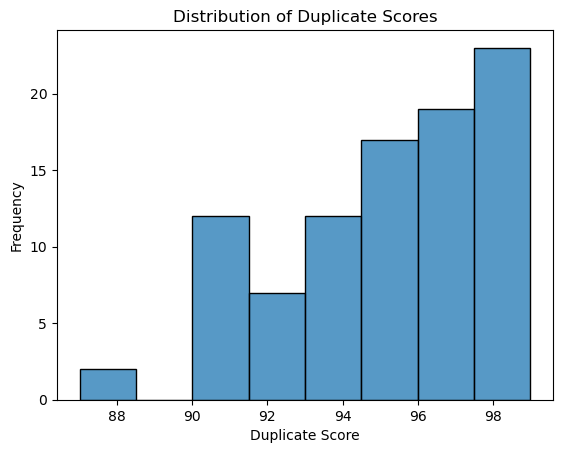

In [52]:
# Just the duplicates included in this plot, isn't the duplicate scores from 0 - 100
sns.histplot(df_fuzzy_name_email_dupes['duplicate_score'], bins=8,)
plt.title('Distribution of Duplicate Scores')
plt.xlabel('Duplicate Score')
plt.ylabel('Frequency')
plt.show()


# Probabilistic Record Linkage for deduplication

In [53]:
# BY ASCOTT
# https://recordlinkage.readthedocs.io/en/latest/guides/data_deduplication.html
# https://medium.com/@johnthuo/exploring-record-linkage-in-python-2f70317fd348
# https://www.robinlinacre.com/intro_to_probabilistic_linkage/

### Looking at the names of people to determine if duplicates using record linkage similarity

#### Only going to apply this method to those records with all 3 names, as it's likely that people mat share first name and last name, assumption here is that the middle name is then the unique identifier. It's unlikely that people will have all 3 names in common, but it is possible

In [54]:

# so the record linkage isn't affected
df_cleaned_1['middle_name'].replace('', np.nan, inplace=True)

# in order to compare all records
indexer = recordlinkage.Index()
indexer.full() 

candidate_links = indexer.index(df_cleaned_1)

# comparison rules
compare = recordlinkage.Compare()
compare.string('first_name', 'first_name', method='jarowinkler', label='first_name')
# missing value of 0.5 for middle name as its random if its there or not
compare.string('middle_name', 'middle_name', method='jarowinkler', label='middle_name', missing_value=0.5)  
compare.string('last_name', 'last_name', method='jarowinkler', label='last_name')

# simlarity scores computed from comparison rules and the method
comparison_results = compare.compute(candidate_links, df_cleaned_1)



# filtering similarity greater than 0.85 for first_name last_name and middle_name
filtered_duplicates = comparison_results[
    (comparison_results['first_name'] >= 0.85) & (comparison_results['last_name'] >= 0.85) & (comparison_results['middle_name']>= 0.85)
]

# filtering similarity greater than 0.85 for first_name last_name and middle_name
filtered_duplicates_plot = comparison_results[
    (comparison_results['first_name'] >= 0) & (comparison_results['last_name'] >= 0) & (comparison_results['middle_name']>= 0)
]

# Sort by highest similarity
filtered_duplicates = filtered_duplicates.sort_values(by=['first_name', 'last_name'], ascending=False)
filtered_duplicates_plot = filtered_duplicates_plot.sort_values(by=['first_name', 'last_name'], ascending=False)
# Compute a dynamic similarity score (ignoring NaN values)
filtered_duplicates['duplicate_score'] = np.round(comparison_results.mean(axis=1)*100)
filtered_duplicates_plot['duplicate_score'] = np.round(comparison_results.mean(axis=1)*100)

# Display potential duplicates sorted by overall similarity
potential_duplicates = filtered_duplicates[filtered_duplicates['duplicate_score'] >= 85] \
    .sort_values(by='duplicate_score', ascending=False)

# Display results
print(filtered_duplicates_plot)


           first_name  middle_name  last_name  duplicate_score
367  224          1.0     0.630952        1.0             88.0
764  244          1.0     0.500000        1.0             83.0
855  68           1.0     0.500000        1.0             83.0
1129 364          1.0     0.483333        1.0             83.0
1148 884          1.0     0.500000        1.0             83.0
...               ...          ...        ...              ...
3619 3492         0.0     0.500000        0.0             17.0
     3531         0.0     0.500000        0.0             17.0
     3553         0.0     0.500000        0.0             17.0
     3558         0.0     0.511111        0.0             17.0
     3612         0.0     0.000000        0.0              0.0

[6550390 rows x 4 columns]


## Distribution Plot of Duplicate Scores

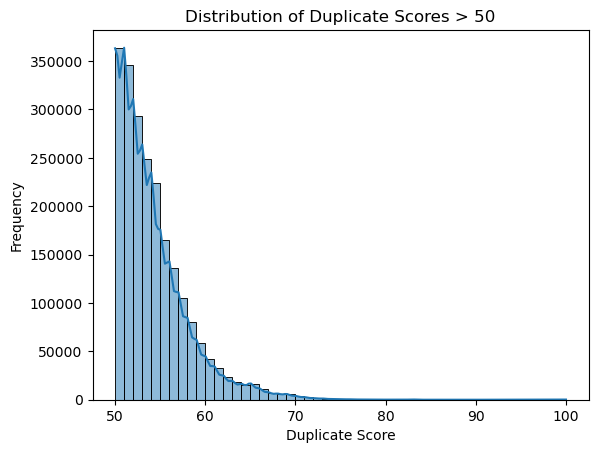

In [55]:
# filtering uplicate scores greater than 50
filtered_df = filtered_duplicates_plot[filtered_duplicates_plot['duplicate_score'] >= 50]

# https://stackoverflow.com/questions/77317195/how-can-i-change-the-distribution-curve-kde-smoothing-of-a-histogram
# Article helped with making the kernal smoothing line look better
sns.histplot(filtered_df['duplicate_score'], kde=True, bins=50, kde_kws={'bw_adjust': 2})
plt.title('Distribution of Duplicate Scores > 50')
plt.xlabel('Duplicate Score')
plt.ylabel('Frequency')
plt.show()



## A case that Fuzzy Matching missed

In [56]:
# Comparing the two with the lowest duplicate score we see that they are infact a duplicate, safe to assume 
# same will apply for those with larger duplicate scores
df_cleaned_1.loc[3333]

house_no                          NaN
primary_street                    NaN
town                              NaN
county                            NaN
postcode                          NaN
prefix                           miss
first_name                       lnyn
middle_name                   natlaie
last_name                      garner
date_of_birth     2001-10-15 00:00:00
phone_number              07700900595
email_address                     NaN
Name: 3333, dtype: object

In [57]:
df_cleaned_1.loc[2868]

house_no                             NaN
primary_street                       NaN
town                                 NaN
county                               NaN
postcode                             NaN
prefix                              miss
first_name                          lynn
middle_name                      natalie
last_name                         garner
date_of_birth        2001-10-15 00:00:00
phone_number                 07700900595
email_address     lynngarner@hotmail.com
Name: 2868, dtype: object

In [58]:
potential_duplicates

,,first_name,middle_name,last_name,duplicate_score
2648,2647,1.000,1.000000,1.0,100.0
3439,2640,1.000,1.000000,1.0,100.0
3443,3407,1.000,1.000000,1.0,100.0
3448,795,1.000,1.000000,1.0,100.0
3450,2939,1.000,1.000000,1.0,100.0
...,...,...,...,...,...
3167,1400,0.940,1.000000,1.0,98.0
3534,3160,0.940,1.000000,1.0,98.0
3092,2436,0.925,1.000000,1.0,98.0
3392,2745,0.925,1.000000,1.0,98.0


In [59]:
# extracting unique index pairs of the potential duplicate records
duplicate_indices = set(potential_duplicates.index.get_level_values(0))

# creating a df of only the duplicate records
df_duplicates = df_cleaned_1.loc[list(duplicate_indices)].copy()

# merging duplicate scores into the df
df_duplicates = df_duplicates.merge(
    filtered_duplicates.reset_index()[['level_0', 'duplicate_score']], 
    left_index=True, right_on='level_0', 
    how='left'
)

# dropping cols
df_duplicates.drop(columns=['level_0'], inplace=True)


df_duplicates.sort_values('duplicate_score')




,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address,duplicate_score
203,NaN,NaN,NaN,NaN,NaN,miss,lnyn,natlaie,garner,2001-10-15,07700900595,NaN,96.0
201,NaN,NaN,NaN,NaN,NaN,mr,robin,charlie,thompson,2005-04-30,07700900298,NaN,98.0
202,NaN,NaN,NaN,NaN,NaN,mr,aaln,stewart,cameron,NaT,07700900734,NaN,98.0
6,NaN,NaN,NaN,NaN,NaN,mr,marc,denis,west,1967-07-17,NaN,mwest@yahoo.com,98.0
200,NaN,NaN,NaN,NaN,NaN,mr,cilve,trevor,long,1962-10-01,NaN,NaN,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,NaN,NaN,NaN,NaN,NaN,mr,justin,terence,howard,2005-11-18,NaN,NaN,100.0
63,NaN,NaN,NaN,NaN,NaN,ms,susan,cheryl,green,NaT,NaN,NaN,100.0
64,NaN,NaN,NaN,NaN,NaN,miss,claire,kelly,carr,1988-01-05,NaN,NaN,100.0
56,NaN,NaN,NaN,NaN,NaN,mr,richard,clive,bryant,NaT,NaN,NaN,100.0


In [60]:
df_duplicates.to_csv('record_linkage_full_name_dupes.csv', index = False)

In [74]:
# moving on lets identify and remove the duplicates by keeping the first record in each pair

duplicate_indices = set()

# looping over each duplicate pair
for idx1, idx2 in potential_duplicates.index:
    missing_count_idx1 = df_cleaned_1.loc[idx1].isna().sum()
    missing_count_idx2 = df_cleaned_1.loc[idx2].isna().sum()

    # removing the row with most missing values
    duplicate_indices.add(idx1 if missing_count_idx1 > missing_count_idx2 else idx2)

# removing duplicates based on the identified indices
df_cleaned_1_no_duplicates = df_cleaned_1.drop(duplicate_indices).reset_index(drop=True)


df_cleaned_1_no_duplicates


,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address
0,1,amber turnpike,clogher,fermanagh,bt935xf,mrs,dawn,danielle,cooper,1971-10-22,07700900484,dawndcooper104@hotmail.com
1,1,carol spurs,capecastle,fermanagh,bt936is,mr,joel jeol,stuart,grant,NaT,NaN,joelsgrant@hotmail.com
2,1,frances square,teemore,antrim,bt379vh,miss,katie,NaN,evans,NaT,07700900190,NaN
3,1,francesca ranch,newry,antrim,bt561ia,mr,kieran,keith,harris,NaT,NaN,kierankharris@outlook.com
4,1,geoffrey bypass,corrinshego,antrim,bt66cw,mr,joel,NaN,smith,2003-01-08,07700900576,joelksmith@hotmail.co.uk
...,...,...,...,...,...,...,...,...,...,...,...,...
3414,NaN,NaN,NaN,NaN,NaN,mrs,sian,nicola,peters,1995-05-17,07700900027,NaN
3415,NaN,NaN,NaN,NaN,NaN,miss,tracey,NaN,marshall,1974-02-03,NaN,NaN
3416,NaN,NaN,NaN,NaN,NaN,mr,darren,v,martin,NaT,07700900632,NaN
3417,NaN,NaN,NaN,NaN,NaN,miss,carole,melissa,ferguson,1984-09-25,NaN,NaN


## When finalising the dataset I did a quick inspection and thought of something that I had not considered when thinking of the phone number

#### Maybe a way around the non unique phone number problem would be to look at where the phone number, first_name and last_name columns are all the same. This would be a reasonable to assume that this is the same person.

In [62]:
# BY ASCOTT
# separating the rows with nans and creating a df
df_phone_number_no_nans = df_cleaned_1_no_duplicates[df_cleaned_1_no_duplicates['phone_number'].notna()]
df_phone_number_nan = df_cleaned_1_no_duplicates[df_cleaned_1_no_duplicates['phone_number'].isna()]

# creating df for aggregated rows done by email address
# applying to whole dataframe, will check for emails with same string, and aggregate data
df_agg_phone_number = df_phone_number_no_nans.groupby(['phone_number', 'first_name', 'last_name'], as_index=False).agg({
    'prefix': lambda x: ' '.join(x.dropna().unique()),  
    'middle_name': lambda x: ' '.join(x.dropna().unique()),  
    'date_of_birth': 'first',  
    'house_no': lambda x: ' '.join(x.dropna().unique()),  
    'primary_street': lambda x: ' '.join(x.dropna().unique()), 
    'town': lambda x: ' '.join(x.dropna().unique()),  
    'postcode': lambda x: ' '.join(x.dropna().unique()),  
    'county': lambda x: ' '.join(x.dropna().unique()),  
    'phone_number': 'first'
})


df_agg_phone_number

,first_name,last_name,prefix,middle_name,date_of_birth,house_no,primary_street,town,postcode,county,phone_number
0,donna,saunders,ms,sheila,NaT,104,elaine plains,wattlebridge,bt515xa,derrylondonderry,07700090335 07700900335
1,bernard,jones,mr,,NaT,,,,,,07700090815
2,callum,hall,mr,paul,NaT,61,white bridge,banbridge,bt926rt,fermanagh,07700900000
3,colin,brown,mr,,1979-02-23,139,jodie island,aghagallon,bt158br,antrim,07700900000
4,garry,talbot,mr,glen,1963-12-11,70,julia parkways,craigavon,bt472ej,derrylondonderry,07700900000
...,...,...,...,...,...,...,...,...,...,...,...
2257,lynne,barnes,ms,,NaT,4,houghton skyway,ballymacnab,bt74xn,antrim,07700900998
2258,mitchell,price,mr,,1996-09-28,64a,ross hollow,ardstraw,bt183zb,down,07700900998
2259,harriet,taylor,miss,,1995-09-16,87,walker pike,lisburn,bt59ay,down,07700900999
2260,james,dixon,mr,craig,NaT,89,maria grove,caledon,bt940hc,fermanagh,07700900999


In [63]:
# Now combining this dataframe with the one that contained nans for phone_number
df_final = pd.concat([df_agg_phone_number, df_phone_number_nan], ignore_index=True)
# remember ran into problem with aggregated dataframe due to empty strings
# applying fix here for future use of the df_loc_aggregated dataframe
df_final = df_final.replace(r'^\s*$', np.nan, regex=True)
df_final

,first_name,last_name,prefix,middle_name,date_of_birth,house_no,primary_street,town,postcode,county,phone_number,email_address
0,donna,saunders,ms,sheila,NaT,104,elaine plains,wattlebridge,bt515xa,derrylondonderry,07700090335 07700900335,NaN
1,bernard,jones,mr,NaN,NaT,NaN,NaN,NaN,NaN,NaN,07700090815,NaN
2,callum,hall,mr,paul,NaT,61,white bridge,banbridge,bt926rt,fermanagh,07700900000,NaN
3,colin,brown,mr,NaN,1979-02-23,139,jodie island,aghagallon,bt158br,antrim,07700900000,NaN
4,garry,talbot,mr,glen,1963-12-11,70,julia parkways,craigavon,bt472ej,derrylondonderry,07700900000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3307,lydia,bryant,miss,NaN,1979-11-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3308,chloe,short,ms,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3309,tracey,marshall,miss,NaN,1974-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3310,carole,ferguson,miss,melissa,1984-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3419 rows in df_cleaned_1_no_duplicates dataframe, now 3312 rows in df_final
### 107 duplicate rows removed with identical entries for for phone number, first name and last name columns

In [64]:
# BY ASCOTT

# getting all the duplicates which have the same phone number and first_name last_name
df_without_number_nas = df_cleaned_1_no_duplicates[df_cleaned_1_no_duplicates['phone_number'].notna()]


# geting only duplicate rows and sorting, same code as before
df_simple_number_names_dupes = df_without_number_nas[df_without_number_nas.duplicated(subset=['phone_number', 'first_name', 'last_name'], keep=False)]

df_simple_number_names_dupes_sorted = df_simple_number_names_dupes.sort_values(['phone_number'])
# adding duplicate score column 
df_simple_number_names_dupes_sorted['duplicate_score'] = 100
df_simple_number_names_dupes_sorted

,house_no,primary_street,town,county,postcode,prefix,first_name,middle_name,last_name,date_of_birth,phone_number,email_address,duplicate_score
3111,NaN,NaN,NaN,NaN,NaN,mr,darren,NaN,clarke,1994-01-07,07700900019,NaN,100
856,160,goodwin drive,brookeborough,fermanagh,bt927lx,mr,darren,NaN,clarke,1994-01-07,07700900019,darrengclarke841@yahoo.co.uk,100
3027,NaN,NaN,NaN,NaN,NaN,mrs,beth,NaN,jackson,2004-09-10,07700900024,NaN,100
2611,NaN,NaN,NaN,NaN,NaN,mrs,beth,NaN,jackson,2004-09-10,07700900024,beth382@gmail.com,100
3196,NaN,NaN,NaN,NaN,NaN,miss,catherine,NaN,wright,NaT,07700900026,NaN,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2631,NaN,NaN,NaN,NaN,NaN,mr,charlie,NaN,reynolds,1985-07-11,07700900979,charlie.reynolds@hotmail.com,100
3092,NaN,NaN,NaN,NaN,NaN,mr,mark,NaN,patel,1965-12-05,07700900983,NaN,100
3306,NaN,NaN,NaN,NaN,NaN,mr,mark,NaN,patel,1965-12-05,07700900983,NaN,100
2798,NaN,NaN,NaN,NaN,NaN,miss,julia,NaN,fisher,1962-09-17,07700900999,julia.fisher@yahoo.co.uk,100


In [65]:
# writing the duplicate name and numbers:
df_simple_number_dupes_sorted.to_csv('identical_num_name_duplicates.csv', index = False)

#### Had a further thought of something that I had not considered after dealing with the phone number and names. 
#### I could do the same for the date_of_birth and the first_name and last_name columns, it's fair to assume that records with the same first_name and last_name and date_of_birth are the same person.

In [66]:
df_birth_no_nans = df_final[df_final['date_of_birth'].notna()]
df_birth_nan = df_final[df_final['date_of_birth'].isna()]

# creating df for aggregated rows done by births and name
# applying to whole dataframe, will check for emails with same string, and aggregate data
df_agg_births_name = df_birth_no_nans.groupby(['date_of_birth', 'first_name', 'last_name'], as_index=False).agg({
    'prefix': lambda x: ' '.join(x.dropna().unique()),  
    'middle_name': lambda x: ' '.join(x.dropna().unique()),  
    'date_of_birth': 'first',  
    'house_no': lambda x: ' '.join(x.dropna().unique()),  
    'primary_street': lambda x: ' '.join(x.dropna().unique()), 
    'town': lambda x: ' '.join(x.dropna().unique()),  
    'postcode': lambda x: ' '.join(x.dropna().unique()),  
    'county': lambda x: ' '.join(x.dropna().unique()),  
    'phone_number': 'first'
})


df_agg_births_name.sort_values('date_of_birth')

,first_name,last_name,prefix,middle_name,date_of_birth,house_no,primary_street,town,postcode,county,phone_number
0,eleanor,mason,mrs,fiona,1955-04-07,,,,,,07700900264
1,samantha,ford,mrs,eleanor,1955-04-10,23b,steele drive,glebe,bt816ih,tyrone,07700900233
2,ellie,evans,mrs,elaine,1955-05-11,60a,jenna corner,drummullan,bt194py,down,07700900281
3,stephen,thomas,mr,,1955-06-01,,,,,,07700900106
4,dawn,webb,miss,,1955-06-02,118,hewitt glens,newtown crommelin,bt493yz,derrylondonderry,None
...,...,...,...,...,...,...,...,...,...,...,...
1286,suzanne,campbell,mrs,,2006-12-29,77,philip rue,knocknacarry,bt742ue,fermanagh,07700900284
1287,jamie,harding,mr,bradley,2007-01-10,62c,gemma parkways,cladymore,bt476uk,derrylondonderry,07700900829
1288,vincent,bennett,mr,,2007-03-01,,,,,,None
1289,scott,douglas,mr,anthony,2007-03-10,181,jill mountain,magheraveely,bt624hn,armagh,07700900823


In [67]:
# Now combining this dataframe with the one that contained nans for phone_number
df_final_final = pd.concat([df_agg_births_name, df_birth_nan], ignore_index=True)
# remember ran into problem with aggregated dataframe due to empty strings
# applying fix here for future use of the df_loc_aggregated dataframe
df_final_final = df_final_final.replace(r'^\s*$', np.nan, regex=True)
df_final_final

,first_name,last_name,prefix,middle_name,date_of_birth,house_no,primary_street,town,postcode,county,phone_number,email_address
0,eleanor,mason,mrs,fiona,1955-04-07,NaN,NaN,NaN,NaN,NaN,07700900264,NaN
1,samantha,ford,mrs,eleanor,1955-04-10,23b,steele drive,glebe,bt816ih,tyrone,07700900233,NaN
2,ellie,evans,mrs,elaine,1955-05-11,60a,jenna corner,drummullan,bt194py,down,07700900281,NaN
3,stephen,thomas,mr,NaN,1955-06-01,NaN,NaN,NaN,NaN,NaN,07700900106,NaN
4,dawn,webb,miss,NaN,1955-06-02,118,hewitt glens,newtown crommelin,bt493yz,derrylondonderry,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3277,joan,ward,mrs,naomi,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3278,rosemary,bruce,miss,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3279,simon,jones,mr,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3280,chloe,short,ms,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3312 rows in df_final dataframe, now 3282 rows in df_final_final
### 30 duplicate rows removed with identical entries for date_of_birth, first name and last name columns

In [68]:

# getting all the duplicates which have the same phone number and first_name last_name
df_without_birth_nas = df_final[df_final['date_of_birth'].notna()]


# geting only duplicate rows and sorting, same code as before
df_birth_names_dupes = df_without_birth_nas[df_without_birth_nas.duplicated(subset=['date_of_birth', 'first_name', 'last_name'], keep=False)]

df_simple_birth_names_dupes_sorted = df_birth_names_dupes.sort_values(['first_name'])
# adding duplicate score column 
df_simple_birth_names_dupes_sorted['duplicate_score'] = 100
df_simple_birth_names_dupes_sorted.head()

,first_name,last_name,prefix,middle_name,date_of_birth,house_no,primary_street,town,postcode,county,phone_number,email_address,duplicate_score
3252,alexander,wood,mr,NaN,1966-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100
2423,alexander,wood,mr,NaN,1966-05-31,14,benjamin village,groggan,bt567vh,antrim,NaN,NaN,100
3028,anthony,mahmood,mr,NaN,2004-02-10,NaN,NaN,NaN,NaN,NaN,NaN,anthony851@outlook.com,100
3182,anthony,mahmood,mr,NaN,2004-02-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100
3208,brenda,cross,miss,NaN,1993-06-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100


In [69]:
# writing the duplicate name and numbers:
df_simple_birth_names_dupes_sorted.to_csv('identical_birth_name_duplicates.csv', index = False)

# Final Cleaned Dataset

In [70]:
# Want to make the dataset presentable again, ie capital letters etc.
cols_to_cap = ['primary_street', 'town', 'county', 'prefix', 'first_name', 'middle_name', 'last_name']

for col in cols_to_cap:
    df_final_final[col] = df_final_final[col].str.title()

df_final_final['postcode'] = df_final_final['postcode'].str.upper()
    
df_final_final

,first_name,last_name,prefix,middle_name,date_of_birth,house_no,primary_street,town,postcode,county,phone_number,email_address
0,Eleanor,Mason,Mrs,Fiona,1955-04-07,NaN,NaN,NaN,NaN,NaN,07700900264,NaN
1,Samantha,Ford,Mrs,Eleanor,1955-04-10,23b,Steele Drive,Glebe,BT816IH,Tyrone,07700900233,NaN
2,Ellie,Evans,Mrs,Elaine,1955-05-11,60a,Jenna Corner,Drummullan,BT194PY,Down,07700900281,NaN
3,Stephen,Thomas,Mr,NaN,1955-06-01,NaN,NaN,NaN,NaN,NaN,07700900106,NaN
4,Dawn,Webb,Miss,NaN,1955-06-02,118,Hewitt Glens,Newtown Crommelin,BT493YZ,Derrylondonderry,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3277,Joan,Ward,Mrs,Naomi,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3278,Rosemary,Bruce,Miss,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3279,Simon,Jones,Mr,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3280,Chloe,Short,Ms,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
df_final_final.to_csv('deduped_analytathon2_final.csv', index = False)

# Combining Duplicate Rows

In [ ]:
df1 = pd.read_csv('fuzzy_name_email_dupes.csv')
df2 = pd.read_csv('identical_address_duplicates.csv')
df3 = pd.read_csv('identical_email_duplicates.csv')
df4 = pd.read_csv('record_linkage_full_name_dupes.csv')
df5 = pd.read_csv('identical_num_name_duplicates.csv')
df6 = pd.read_csv('identical_birth_name_duplicates.csv')

# merging vertically
df_merged = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)
df_merged.sort_values('last_name')

df_merged.to_csv("merged_dupes.csv", index=False)

# Further work

In [72]:

# https://www.researchgate.net/publication/366616223_A_Data_Deduplication_Scheme_Based_On_DBSCAN_With_Tolerable_Clustering_Deviation